# 05 - Model Training, Evaluation, and Batch Deployment

This notebook satisfies the Week 4 project steps:

1. Set up a simple benchmark model.
2. Train a first real sentiment model in SageMaker.
3. Evaluate the trained model against the benchmark.
4. Deploy the trained model with SageMaker Batch Transform.

The workflow uses the train, validation, test, and production CSVs created by `03_feature_engineering_feature_store.ipynb` and verified by `04_dataset_splits.ipynb`.


In [6]:
!pip install --upgrade "sagemaker>=2,<3"

In [1]:
import json
import tarfile
import tempfile
from pathlib import Path

import boto3
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sagemaker
import seaborn as sns
try:
    from sagemaker.inputs import TrainingInput
except ModuleNotFoundError:
    from sagemaker.session import s3_input as TrainingInput
from sagemaker.sklearn.estimator import SKLearn
from sagemaker.sklearn.model import SKLearnModel
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, precision_score, recall_score

from plot_style import PURPLE_DARK, PURPLE_LIGHT, apply_style

apply_style()
pd.set_option("display.max_colwidth", 120)


sagemaker.config INFO - Not applying SDK defaults from location: /etc/xdg/sagemaker/config.yaml


sagemaker.config INFO - Not applying SDK defaults from location: /home/sagemaker-user/.config/sagemaker/config.yaml


## 1. Configure SageMaker and S3 paths

The earlier notebooks store shared variables with `%store`. If a variable is missing, this cell falls back to the known project defaults from the completed Week 3 run.


In [2]:
%store -r bucket
%store -r role
%store -r region

sagemaker_session = sagemaker.Session()
boto_session = boto3.Session()

region = globals().get("region") or boto_session.region_name
role = globals().get("role") or sagemaker.get_execution_role()
bucket = globals().get("bucket") or f"yelp-sentiment-mlops-{boto3.client('sts').get_caller_identity()['Account']}"

split_prefix = "processed/splits"
model_prefix = "models/week4-sklearn-sentiment"
batch_prefix = "batch/week4-sentiment"
report_dir = Path("../reports")
report_dir.mkdir(parents=True, exist_ok=True)

train_s3 = f"s3://{bucket}/{split_prefix}/train/train.csv"
validation_s3 = f"s3://{bucket}/{split_prefix}/validation/validation.csv"
test_s3 = f"s3://{bucket}/{split_prefix}/test/test.csv"
production_s3 = f"s3://{bucket}/{split_prefix}/production/production.csv"
batch_input_s3 = f"s3://{bucket}/{batch_prefix}/input/production_text.txt"
batch_output_s3 = f"s3://{bucket}/{batch_prefix}/output/"

print("Region:", region)
print("Bucket:", bucket)
print("Role:", role)
print("Train:", train_s3)
print("Validation:", validation_s3)
print("Test:", test_s3)
print("Production:", production_s3)


no stored variable or alias role


Region: us-east-1
Bucket: yelp-sentiment-mlops-045456814877
Role: arn:aws:iam::045456814877:role/LabRole
Train: s3://yelp-sentiment-mlops-045456814877/processed/splits/train/train.csv
Validation: s3://yelp-sentiment-mlops-045456814877/processed/splits/validation/validation.csv
Test: s3://yelp-sentiment-mlops-045456814877/processed/splits/test/test.csv
Production: s3://yelp-sentiment-mlops-045456814877/processed/splits/production/production.csv


## 2. Load split data

These are the materialized split files from S3. The production split is reserved for batch scoring to simulate production inference.


In [3]:
train_df = pd.read_csv(train_s3)
validation_df = pd.read_csv(validation_s3)
test_df = pd.read_csv(test_s3)
production_df = pd.read_csv(production_s3)

for name, df in {
    "train": train_df,
    "validation": validation_df,
    "test": test_df,
    "production": production_df,
}.items():
    print(f"{name:10s} rows={len(df):,} positive_share={df['sentiment_label'].mean():.3f}")

train_df.head()


train      rows=20,000 positive_share=0.500
validation rows=5,000 positive_share=0.500
test       rows=5,000 positive_share=0.500
production rows=20,000 positive_share=0.500


,review_id,business_id,user_id,stars,sentiment,sentiment_label,review_text,clean_text,review_char_length,review_word_count,has_exclamation,has_question,review_year,split_type,event_time
0,EA_ijm26Wi-L-Whgz5KP3A,vwWPyZSLtggyIFzmhk4PLQ,alUlVVMx9NtfrvK4xAQy2w,2.0,negative,0,"I love Mexican food but this place was just bad. I understand the concept of this kind of restaurant, almost like a ...","i love mexican food but this place was just bad. i understand the concept of this kind of restaurant, almost like a ...",727,142,0,0,2015,train,2026-05-26T01:05:20Z
1,F80m3A6UxRxDsuDaL55vUw,UmjITdXHhEF46ho6IhaGQg,koRCG1RumdJ8dDXwfYaVuA,2.0,negative,0,"I come to D&B often with friends just to eat! There is always a very long wait, but service usually makes up for it....","i come to d&b often with friends just to eat! there is always a very long wait, but service usually makes up for it....",1644,321,1,0,2018,train,2026-05-26T01:05:20Z
2,m_YhQl1nY4mQOAGdG_kxsQ,J-ciDDEdIHMcChGIyKZnOg,ybZ8bRWxjJVAxJhpMyqUgg,5.0,positive,1,"Cake Life has the goods you're seeking. Birthday cakes, wedding cakes, cupcakes, and pastries for all occasions. C...","cake life has the goods you're seeking. birthday cakes, wedding cakes, cupcakes, and pastries for all occasions. che...",1110,189,1,1,2017,train,2026-05-26T01:05:20Z
3,ILRaT5eKQ-o_ddDiNLsdOg,Q8q-1MZTYPL9ZBmAeoMKVg,JUXsB550wIDctZ_BClXMug,2.0,negative,0,I came here early on a Sunday and there was a wait (which was fine) for my mani/pedi. The staff sat my down in a cha...,i came here early on a sunday and there was a wait (which was fine) for my mani/pedi. the staff sat my down in a cha...,840,163,0,0,2016,train,2026-05-26T01:05:20Z
4,4DNTLyNrU-HlGSsv0J4GNg,AfassS1QI0DHsqwuof9-lA,wtV7XGwsSgH63QyIKzopIg,2.0,negative,0,I've been here a few times with my boyfriend. Drinks are cheap and decent. The bartenders usually alright not friend...,i've been here a few times with my boyfriend. drinks are cheap and decent. the bartenders usually alright not friend...,590,110,1,1,2017,train,2026-05-26T01:05:20Z


## 3. Benchmark model

The benchmark is intentionally simple. It predicts the majority class observed in the training set. This gives us a minimum baseline that the trained model must beat.


In [4]:
LABELS = [0, 1]

def metric_row(model_name, split_name, y_true, y_pred):
    return {
        "model": model_name,
        "split": split_name,
        "row_count": int(len(y_true)),
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
    }

majority_label = int(train_df["sentiment_label"].mode().iloc[0])
benchmark_rows = []
benchmark_confusion = None

for split_name, df in {"validation": validation_df, "test": test_df}.items():
    y_true = df["sentiment_label"].astype(int)
    y_pred = np.full(len(df), majority_label)
    benchmark_rows.append(metric_row("majority_class_benchmark", split_name, y_true, y_pred))
    if split_name == "test":
        benchmark_confusion = confusion_matrix(y_true, y_pred, labels=LABELS)

benchmark_metrics = pd.DataFrame(benchmark_rows)
display(benchmark_metrics)
print("Benchmark majority label:", majority_label)


,model,split,row_count,accuracy,precision_macro,recall_macro,f1_macro
0,majority_class_benchmark,validation,5000,0.5,0.25,0.5,0.333333
1,majority_class_benchmark,test,5000,0.5,0.25,0.5,0.333333


Benchmark majority label: 0


## 4. Train the first real model in SageMaker

This launches a SageMaker SKLearn training job using `src/train_sklearn.py`. The model is a TF-IDF vectorizer plus Logistic Regression classifier.


In [5]:
estimator = SKLearn(
    entry_point="train_sklearn.py",
    source_dir="../src",
    role=role,
    instance_type="ml.m5.large",
    instance_count=1,
    framework_version="1.2-1",
    py_version="py3",
    sagemaker_session=sagemaker_session,
    output_path=f"s3://{bucket}/{model_prefix}/artifacts",
    hyperparameters={
        "max-features": 50000,
        "ngram-max": 2,
        "c": 1.0,
        "max-iter": 1000,
    },
)

training_inputs = {
    "train": TrainingInput(train_s3, content_type="text/csv"),
    "validation": TrainingInput(validation_s3, content_type="text/csv"),
    "test": TrainingInput(test_s3, content_type="text/csv"),
}

estimator.fit(training_inputs)
model_artifact_s3 = estimator.model_data
print("Model artifact:", model_artifact_s3)


INFO:sagemaker:Creating training-job with name: sagemaker-scikit-learn-2026-05-30-05-10-35-293


2026-05-30 05:10:38 Starting - Starting the training job.

.

.


2026-05-30 05:10:53 Starting - Preparing the instances for training.

...

.


2026-05-30 05:12:52 Training - Training image download completed. Training in progress./miniconda3/lib/python3.9/site-packages/sagemaker_containers/_server.py:22: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
2026-05-30 05:12:53,797 sagemaker-containers INFO     Imported framework sagemaker_sklearn_container.training
2026-05-30 05:12:53,801 sagemaker-training-toolkit INFO     No GPUs detected (normal if no gpus installed)
2026-05-30 05:12:53,804 sagemaker-training-toolkit INFO     No Neurons detected (normal if no neurons installed)
2026-05-30 05:12:53,821 sagemaker_sklearn_container.training INFO     Invoking user training script.
2026-05-30 05:12:54,066 sagemaker-training-toolkit INFO     No GPUs detected (normal if no gpus installed)
2026-05-30 05:12:54,069 sagemaker

{
  "model_type": "tfidf_logistic_regression",
  "hyperparameters": {
    "max_features": 50000,
    "ngram_range": [
      1,
      2
    ],
    "c": 1.0,
    "max_iter": 1000
  },
  "train_rows": 20000,
  "validation": {
    "row_count": 5000,
    "accuracy": 0.939,
    "precision_macro": 0.9391181052055761,
    "recall_macro": 0.9390000000000001,
    "f1_macro": 0.938995898084187,
    "confusion_matrix": [
      [
        2368,
        132
      ],
      [
        173,
        2327
      ]
    ],
    "labels": [
      0,
      1
    ]
  },
  "test": {
    "row_count": 5000,
    "accuracy": 0.9408,
    "precision_macro": 0.9409492877908745,
    "recall_macro": 0.9408,
    "f1_macro": 0.9407949888878595,
    "confusion_matrix": [
      [
        2375,
        125
      ],
      [
        171,
        2329
      ]
    ],
    "labels": [
      0,
      1
    ]
  }
}
2026-05-30 05:13:07,234 sagemaker-containers INFO     Reporting training SUCCESS



2026-05-30 05:13:26 Uploading - Uploading generated training model
2026-05-30 05:13:26 Completed - Training job completed


Training seconds: 129
Billable seconds: 129
Model artifact: s3://yelp-sentiment-mlops-045456814877/models/week4-sklearn-sentiment/artifacts/sagemaker-scikit-learn-2026-05-30-05-10-35-293/output/model.tar.gz


## 5. Compare benchmark and trained model

The training script writes `metrics.json` into the model artifact. This cell downloads the artifact, extracts the metrics, and saves comparison outputs under `reports/`.


In [6]:
def download_s3_uri(s3_uri, local_path):
    if not s3_uri.startswith("s3://"):
        raise ValueError(f"Expected S3 URI, got {s3_uri}")
    bucket_name, key = s3_uri.replace("s3://", "", 1).split("/", 1)
    boto3.client("s3").download_file(bucket_name, key, str(local_path))

with tempfile.TemporaryDirectory() as tmpdir:
    tmpdir = Path(tmpdir)
    artifact_path = tmpdir / "model.tar.gz"
    extract_dir = tmpdir / "model"
    download_s3_uri(model_artifact_s3, artifact_path)
    extract_dir.mkdir(parents=True, exist_ok=True)
    with tarfile.open(artifact_path, "r:gz") as tar:
        tar.extractall(extract_dir)
    trained_metrics = json.loads((extract_dir / "metrics.json").read_text())
    trained_model = joblib.load(extract_dir / "model.joblib")

trained_rows = []
for split_name in ["validation", "test"]:
    metrics = trained_metrics[split_name]
    trained_rows.append(
        {
            "model": "tfidf_logistic_regression",
            "split": split_name,
            "row_count": metrics["row_count"],
            "accuracy": metrics["accuracy"],
            "precision_macro": metrics["precision_macro"],
            "recall_macro": metrics["recall_macro"],
            "f1_macro": metrics["f1_macro"],
        }
    )

metrics_df = pd.concat([benchmark_metrics, pd.DataFrame(trained_rows)], ignore_index=True)
metrics_path = report_dir / "benchmark_vs_model_metrics.csv"
metrics_df.to_csv(metrics_path, index=False)
display(metrics_df)
print("Wrote", metrics_path)


/tmp/ipykernel_1164/3817754895.py:14: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(extract_dir)
/opt/conda/lib/python3.12/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator TfidfTransformer from version 1.2.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


/opt/conda/lib/python3.12/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator TfidfVectorizer from version 1.2.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/opt/conda/lib/python3.12/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator LogisticRegression from version 1.2.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/opt/conda/lib/python3.12/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator Pipeline from version 1.2.1 when using version 1.7.2. This might lead to breaking code or i

,model,split,row_count,accuracy,precision_macro,recall_macro,f1_macro
0,majority_class_benchmark,validation,5000,0.5000,0.250000,0.5000,0.333333
1,majority_class_benchmark,test,5000,0.5000,0.250000,0.5000,0.333333
2,tfidf_logistic_regression,validation,5000,0.9390,0.939118,0.9390,0.938996
3,tfidf_logistic_regression,test,5000,0.9408,0.940949,0.9408,0.940795


Wrote ../reports/benchmark_vs_model_metrics.csv


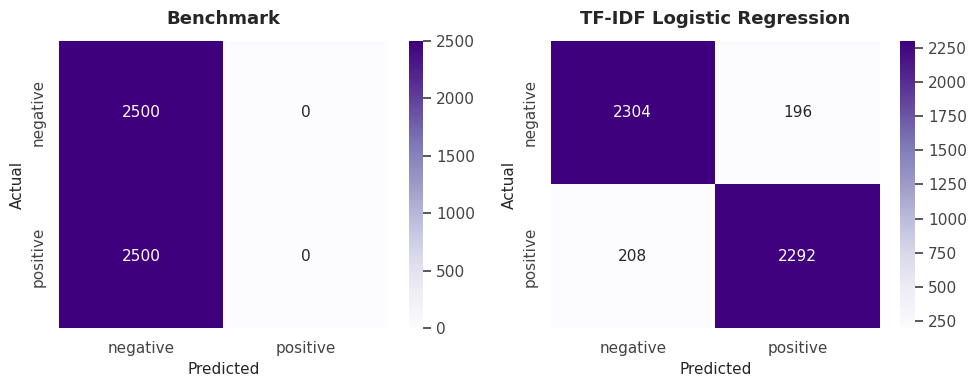

Wrote ../reports/confusion_matrix.png


In [7]:
y_test = test_df["sentiment_label"].astype(int)
y_test_pred = trained_model.predict(test_df["clean_text"].fillna("").astype(str))
model_confusion = confusion_matrix(y_test, y_test_pred, labels=LABELS)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.heatmap(
    benchmark_confusion,
    annot=True,
    fmt="d",
    cmap="Purples",
    xticklabels=["negative", "positive"],
    yticklabels=["negative", "positive"],
    ax=axes[0],
)
axes[0].set_title("Benchmark")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

sns.heatmap(
    model_confusion,
    annot=True,
    fmt="d",
    cmap="Purples",
    xticklabels=["negative", "positive"],
    yticklabels=["negative", "positive"],
    ax=axes[1],
)
axes[1].set_title("TF-IDF Logistic Regression")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
confusion_path = report_dir / "confusion_matrix.png"
plt.savefig(confusion_path, dpi=150)
plt.show()
print("Wrote", confusion_path)


## 6. Batch Transform deployment

The production split is written as one cleaned review per line and scored with SageMaker Batch Transform. This avoids keeping a real-time endpoint running while still demonstrating deployment.


In [8]:
production_text = production_df["clean_text"].fillna("").astype(str).str.replace(r"\s+", " ", regex=True)
local_batch_input = Path("/tmp/production_text.txt")
local_batch_input.write_text("\n".join(production_text.tolist()) + "\n", encoding="utf-8")

bucket_name, key_prefix = batch_input_s3.replace("s3://", "", 1).split("/", 1)
boto3.client("s3").upload_file(str(local_batch_input), bucket_name, key_prefix)
print("Uploaded batch input:", batch_input_s3)

sklearn_model = SKLearnModel(
    model_data=model_artifact_s3,
    role=role,
    entry_point="inference.py",
    source_dir="../src",
    framework_version="1.2-1",
    py_version="py3",
    sagemaker_session=sagemaker_session,
)

transformer = sklearn_model.transformer(
    instance_count=1,
    instance_type="ml.m5.large",
    output_path=batch_output_s3,
    accept="application/json",
    assemble_with="Line",
)

transformer.transform(
    data=batch_input_s3,
    content_type="text/plain",
    split_type="Line",
    wait=True,
)

print("Batch Transform output:", transformer.output_path)


Uploaded batch input: s3://yelp-sentiment-mlops-045456814877/batch/week4-sentiment/input/production_text.txt


INFO:sagemaker:Creating model with name: sagemaker-scikit-learn-2026-05-30-05-13-57-505


INFO:sagemaker:Creating transform job with name: sagemaker-scikit-learn-2026-05-30-05-13-58-189


.

.

...

.

.

/miniconda3/lib/python3.9/site-packages/sagemaker_containers/_server.py:22: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
2026-05-30 05:18:54,612 INFO - sagemaker-containers - No GPUs detected (normal if no gpus installed)
2026-05-30 05:18:54,615 INFO - sagemaker-containers - No GPUs detected (normal if no gpus installed)
2026-05-30 05:18:54,616 INFO - sagemaker-containers - nginx config: 
worker_processes auto;
daemon off;
pid /tmp/nginx.pid;
error_log  /dev/stderr;
worker_rlimit_nofile 4096;
events {
  worker_connections 2048;
}
http {
  include /etc/nginx/mime.types;
  default_type application/octet-stream;
  access_log /dev/stdout combined;
  upstream gunicorn {
    server unix:/tmp/gunicorn.sock;
  }
  server {
    listen 8080 deferred;
    client_max_body_size 0;
 

169.254.255.130 - - [30/May/2026:05:19:08 +0000] "GET /execution-parameters HTTP/1.1" 404 232 "-" "Go-http-client/1.1"
169.254.255.130 - - [30/May/2026:05:19:08 +0000] "GET /execution-parameters HTTP/1.1" 404 232 "-" "Go-http-client/1.1"
2026-05-30T05:19:08.512:[sagemaker logs]: MaxConcurrentTransforms=1, MaxPayloadInMB=6, BatchStrategy=MULTI_RECORD
169.254.255.130 - - [30/May/2026:05:19:12 +0000] "POST /invocations HTTP/1.1" 200 1582517 "-" "Go-http-client/1.1"
169.254.255.130 - - [30/May/2026:05:19:12 +0000] "POST /invocations HTTP/1.1" 200 1582517 "-" "Go-http-client/1.1"


Batch Transform output: s3://yelp-sentiment-mlops-045456814877/batch/week4-sentiment/output/


## 7. Save Week 4 summary

This summary can be used in the Team Tracker and final deliverables.


In [11]:
best_test = metrics_df[(metrics_df["model"] == "tfidf_logistic_regression") & (metrics_df["split"] == "test")].iloc[0]
benchmark_test = metrics_df[(metrics_df["model"] == "majority_class_benchmark") & (metrics_df["split"] == "test")].iloc[0]

summary_lines = [
    "# Week 4 Model Evaluation and Deployment Summary",
    "",
    "## Required Steps",
    "",
    "- Simple benchmark model: majority-class benchmark.",
    "- First real model: SageMaker SKLearn TF-IDF + Logistic Regression training job.",
    "- Evaluation: accuracy, macro precision, macro recall, macro F1, and confusion matrix.",
    "- Deployment: SageMaker Batch Transform using the reserved production split.",
    "",
    "## Test Metrics",
    "",
    f"- Benchmark macro F1: {benchmark_test['f1_macro']:.4f}",
    f"- Trained model macro F1: {best_test['f1_macro']:.4f}",
    f"- Trained model accuracy: {best_test['accuracy']:.4f}",
    "",
    "## Artifacts",
    "",
    f"- Model artifact: `{model_artifact_s3}`",
    f"- Batch input: `{batch_input_s3}`",
    f"- Batch output: `{transformer.output_path}`",
    "- Metrics CSV: `reports/benchmark_vs_model_metrics.csv`",
    "- Confusion matrix: `reports/confusion_matrix.png`",
]

summary_path = report_dir / "model_evaluation_summary.md"
summary_path.write_text("\n".join(summary_lines) + "\n", encoding="utf-8")
print("Wrote", summary_path)
print("\n".join(summary_lines))

Wrote ../reports/model_evaluation_summary.md
# Week 4 Model Evaluation and Deployment Summary

## Required Steps

- Simple benchmark model: majority-class benchmark.
- First real model: SageMaker SKLearn TF-IDF + Logistic Regression training job.
- Evaluation: accuracy, macro precision, macro recall, macro F1, and confusion matrix.
- Deployment: SageMaker Batch Transform using the reserved production split.

## Test Metrics

- Benchmark macro F1: 0.3333
- Trained model macro F1: 0.9408
- Trained model accuracy: 0.9408

## Artifacts

- Model artifact: `s3://yelp-sentiment-mlops-045456814877/models/week4-sklearn-sentiment/artifacts/sagemaker-scikit-learn-2026-05-30-05-10-35-293/output/model.tar.gz`
- Batch input: `s3://yelp-sentiment-mlops-045456814877/batch/week4-sentiment/input/production_text.txt`
- Batch output: `s3://yelp-sentiment-mlops-045456814877/batch/week4-sentiment/output/`
- Metrics CSV: `reports/benchmark_vs_model_metrics.csv`
- Confusion matrix: `reports/confusion_matrix.p